<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/chemistry_methane_CH4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Methane (CH₄)**

[Methane](https://en.m.wikipedia.org/wiki/Methane) (CH₄) has a Tetrahedral geometry with equal C-H bond lengths.

![science](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9b/Methane-2D-dimensions.svg/320px-Methane-2D-dimensions.svg.png)

In [ ]:
!pip install pyscf -q

**Emission and Absorption Lines**

converged SCF energy = -39.726715311543


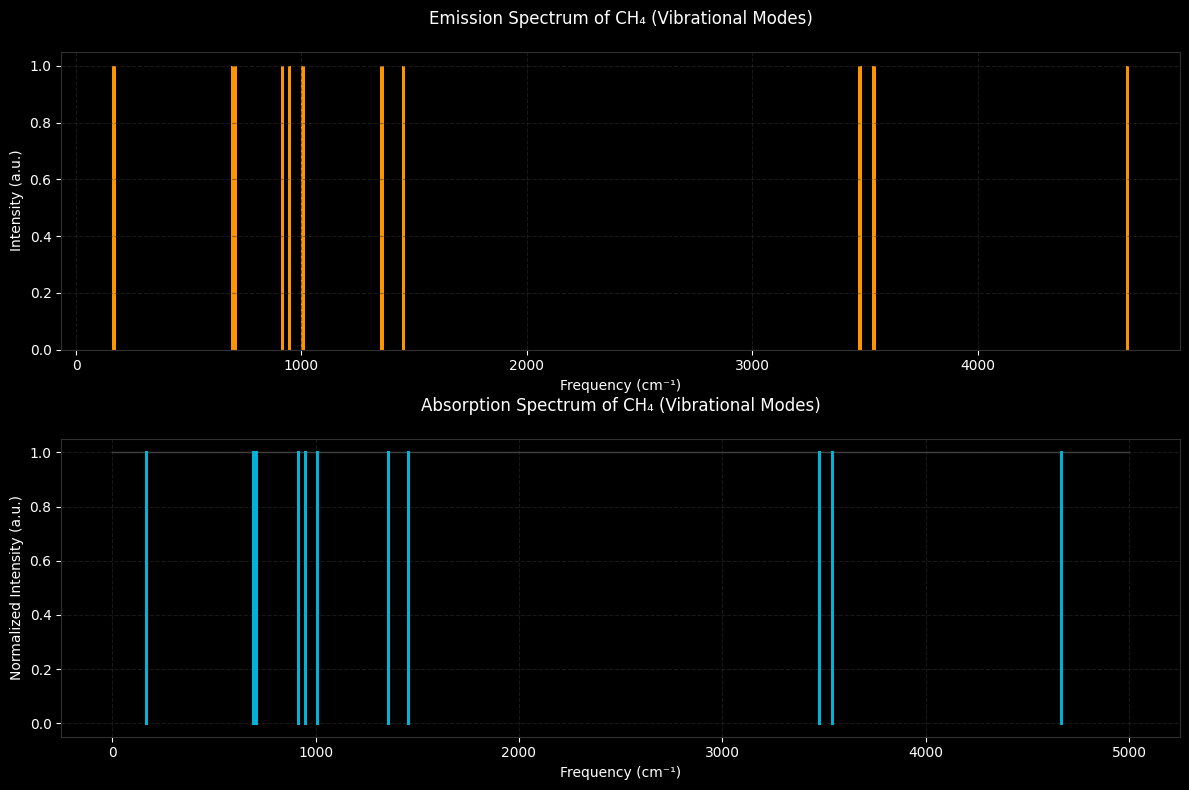

In [ ]:
# Emission and Absorption Spectra (Electronic Frequencies / Transitions)
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, hessian

# Custom colors
EMISSION_COLOR = '#ff9500'  # Bright orange
ABSORPTION_COLOR = '#00b4d8'  # Bright blue
BASELINE_COLOR = '#404040'  # Dark gray
GRID_COLOR = '#303030'  # Slightly lighter gray for grid

# Step 1: Define the molecule
mol = gto.Mole()
mol.atom = '''
    C  0.000000  0.000000  0.000000
    H  0.629118  0.629118  0.629118
    H -0.629118 -0.629118  0.629118
    H -0.629118  0.629118 -0.629118
    H  0.629118 -0.629118 -0.629118
'''
mol.atom = mol.atom
mol.basis = 'sto-3g'
mol.symmetry = True
mol.build()

# Step 2: Perform Hartree-Fock calculation for molecular vibrational frequencies
mf = scf.RHF(mol)
mf.kernel()

# Step 3: Calculate the Hessian matrix (force constants)
hess = hessian.RHF(mf).kernel()

# Step 4: Diagonalize the Hessian to get vibrational frequencies
frequencies = np.linalg.eigvalsh(hess)
frequencies = np.sqrt(np.abs(frequencies)) * 5140.48  # Conversion factor to cm^-1 (more accurate)

# Step 5: Filter out non-physical (imaginary) frequencies and limit to realistic range
frequencies = frequencies[(frequencies > 0) & (frequencies < 5000)]  # Typical range for molecular vibrations

# Create figure with dark background
plt.figure(figsize=(12, 8), facecolor='black')
# Set the style to dark background
plt.style.use('dark_background')

# Emission Spectrum
plt.subplot(2, 1, 1)
plt.bar(frequencies, height=1.0, width=15.0, color=EMISSION_COLOR, alpha=0.8)
plt.xlabel('Frequency (cm⁻¹)', color='white', fontsize=10)
plt.ylabel('Intensity (a.u.)', color='white', fontsize=10)
plt.title('Emission Spectrum of CH₄ (Vibrational Modes)',
         color='white', pad=20, fontsize=12)

# Customize grid and spines
plt.grid(True, color=GRID_COLOR, linestyle='--', alpha=0.5)
for spine in plt.gca().spines.values():
    spine.set_color(GRID_COLOR)
plt.tick_params(colors='white')

# Absorption Spectrum
plt.subplot(2, 1, 2)
# Create baseline
plt.plot(np.linspace(0, 5000, 1000), np.ones(1000),
         color=BASELINE_COLOR, linewidth=1)

# Plot absorption lines with gradient effect
for freq in frequencies:
    y = np.linspace(0, 1, 100)
    x = np.ones_like(y) * freq
    plt.plot(x, y, color=ABSORPTION_COLOR,
            alpha=0.8, linewidth=2)

plt.xlabel('Frequency (cm⁻¹)', color='white', fontsize=10)
plt.ylabel('Normalized Intensity (a.u.)', color='white', fontsize=10)
plt.title('Absorption Spectrum of CH₄ (Vibrational Modes)',
         color='white', pad=20, fontsize=12)

# Customize grid and spines
plt.grid(True, color=GRID_COLOR, linestyle='--', alpha=0.5)
for spine in plt.gca().spines.values():
    spine.set_color(GRID_COLOR)
plt.tick_params(colors='white')

# Adjust layout and display
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

# Set figure background to black
plt.gcf().patch.set_facecolor('black')

plt.show()

**Ground State Energies**

In [ ]:
from pyscf import gto, dft

# Density Functional Theory (DFT) self-consistent field (SCF)

# Define the methane molecule (CH₄)
mol = gto.Mole()
mol.atom = '''
    C  0.0000000   0.0000000   0.0000000
    H  0.6291180   0.6291180   0.6291180
    H -0.6291180  -0.6291180   0.6291180
    H  0.6291180  -0.6291180  -0.6291180
    H -0.6291180   0.6291180  -0.6291180
'''
mol.basis = 'cc-pvdz'
mol.verbose = 4
mol.build()

# Perform a DFT calculation using the B3LYP functional
mf = dft.RKS(mol)
mf.xc = 'b3lyp'
energy = mf.kernel()

print(f"DFT energy for Methane (CH₄) using B3LYP: {energy} Hartree")

System: uname_result(system='Linux', node='e35026d2a300', release='6.1.85+', version='#1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024', machine='x86_64')  Threads 2
Python 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
numpy 1.26.4  scipy 1.13.1  h5py 3.12.1
Date: Sun Dec  8 15:32:44 2024
PySCF version 2.7.0
PySCF path  /usr/local/lib/python3.10/dist-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 5
[INPUT] num. electrons = 10
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 C      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0
[INPUT]  2 H      0.629118000000   0.629118000000   0.629118000000 AA    1.188860720034   1.188860720034   1.188860720034 Bohr   0.0

/usr/local/lib/python3.10/dist-packages/pyscf/dft/libxc.py:507: UserWarning: Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, corresponding to the original definition by Stephens et al. (issue 1480) and the same as the B3LYP functional in Gaussian. To restore the VWN5 definition, you can put the setting "B3LYP_WITH_VWN5 = True" in pyscf_conf.py
  warnings.warn('Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, '


tot grids = 53352
init E= -40.3265497339612
  HOMO = -0.450070919412343  LUMO = 0.032821017242125
cycle= 1 E= -40.4934798636254  delta_E= -0.167  |g|= 0.286  |ddm|= 1.67
  HOMO = -0.333471399389976  LUMO = 0.0956593508606899
cycle= 2 E= -40.4864319648246  delta_E= 0.00705  |g|= 0.329  |ddm|= 0.493
  HOMO = -0.389912679381464  LUMO = 0.0748767479691587
cycle= 3 E= -40.5160832307139  delta_E= -0.0297  |g|= 0.00145  |ddm|= 0.258
  HOMO = -0.390017976742797  LUMO = 0.0748319431707191
cycle= 4 E= -40.5160837646016  delta_E= -5.34e-07  |g|= 0.000322  |ddm|= 0.00275
  HOMO = -0.390148389617707  LUMO = 0.0747750534319549
cycle= 5 E= -40.516083794287  delta_E= -2.97e-08  |g|= 6.72e-06  |ddm|= 0.000243
  HOMO = -0.390143370726239  LUMO = 0.074777090885588
cycle= 6 E= -40.5160837943047  delta_E= -1.76e-11  |g|= 4.74e-07  |ddm|= 1.29e-05
  HOMO = -0.390143723612153  LUMO = 0.074776928806594
Extra cycle  E= -40.5160837943045  delta_E= 1.49e-13  |g|= 4.98e-07  |ddm|= 6.73e-07
converged SCF energy = 